In [1]:
# %matplotlib inline
%matplotlib widget
%config InlineBackend.figure_format = 'retina'

In [2]:
import copy
import json
import math
import random
from collections import Counter, defaultdict
from pathlib import Path
from statistics import mean
from typing import NotRequired, TypedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspiel
import torch
import torch.nn as nn
from torch.distributions import Categorical
from tqdm.auto import tqdm, trange

from cleptoninja import Auction, CleptoNinjaState, Phase
from cleptoninja import register_game as register_cleptoninja_game
from player import GreedyPlayer, Player, RandomPlayer

In [3]:
# TODO: Model players as a dataclass, hold their hands there. adapt rest of code
# TODO: Have auction resolution whithin dataclass. Query from game for card redistribution
# TODO: Change if phase ... for pattern matching everywhere

In [4]:
register_cleptoninja_game()

# Train


## State encoding


In [5]:
def flatten(xs):
    out = []
    stack = [xs]
    while stack:
        cur = stack.pop()
        if isinstance(cur, list):
            stack.extend(reversed(cur))
        else:
            out.append(cur)
    return out

In [6]:
def onehot(index, size, offset=0):
    res = [0] * size
    if index is not None:
        res[index + offset] = 1

    return res


def multihot(cards, size, offset=0):
    res = [0] * size
    for index, count in Counter(cards).items():
        res[index + offset] = count

    return res


def encode_auction(
    auction: Auction, player_index: int, player_count: int, max_card_value: int
) -> list[int | float]:
    auctioneer_onehot = onehot(auction.auctioneer, player_count)
    show_offer_private = int(
        auction.auctioneer == player_index or auction.all_bids_received
    )
    offer = [
        onehot(auction.offer_public, max_card_value, offset=-1),
        onehot(
            auction.offer_private if show_offer_private else None,
            max_card_value,
            offset=-1,
        ),
    ]

    missing_bids_count = auction.expected_bid_count - len(auction.bids)
    is_bid_pressent = [1] * len(auction.bids) + [0] * missing_bids_count
    is_bid_visible = [
        int(bid.bidder == player_index or auction.all_bids_received)
        for bid in auction.bids
    ] + [0] * missing_bids_count
    bids_cards = [
        bid.cards if show_bid else []
        for show_bid, bid in zip(is_bid_visible, auction.bids)
    ] + [[]] * missing_bids_count
    bids_multihot = [multihot(cards, max_card_value, offset=-1) for cards in bids_cards]
    bid_values = [sum(cards) / (2 * max_card_value) for cards in bids_cards]

    encoded = flatten(
        [
            auctioneer_onehot,
            show_offer_private,
            offer,
            auction.expected_bid_count,
            missing_bids_count / (player_count - 1),
            bids_multihot,
            bid_values,
            is_bid_pressent,
            is_bid_visible,
        ]
    )
    return encoded


def empty_encoded_auction(player_count, max_card_value) -> list[int | float]:
    expected_bid_count = player_count - 1
    bids_multihot = [
        multihot([], max_card_value, offset=-1) for _ in range(expected_bid_count)
    ]

    encoded = flatten(
        [
            [0] * player_count,  # auctioneer_onehot
            0,  # show_offer_private
            [[0] * max_card_value, [0] * max_card_value],  # offer
            expected_bid_count,
            1,  # missing_bids_ration
            bids_multihot,
            [0] * expected_bid_count,  # bid_values
            [0] * expected_bid_count,  # is_bid_present
            [0] * expected_bid_count,  # is_bid_visible
        ]
    )
    return encoded


def encode_observation(state: CleptoNinjaState, player_index: int) -> list[int | float]:
    player_count = len(state._hands)
    max_card_value = state.max_card

    phase_onehot = onehot(0 if state._phase == Phase.OFFER else 1, size=2)
    round_one_hot = onehot(state._round, player_count)
    player_onehot = onehot(player_index, player_count)
    hand_multihot = multihot(state._hands[player_index], max_card_value, offset=-1)

    auctions = [
        encode_auction(auction, player_index, player_count, max_card_value)
        for auction in state._auctions
    ]
    missing_auctions_count = player_count - len(auctions)
    auctions += [
        empty_encoded_auction(player_count, max_card_value)
        for _ in range(missing_auctions_count)
    ]

    encoded = (
        phase_onehot
        + round_one_hot
        + player_onehot
        + hand_multihot
        + flatten(auctions)
        + [missing_auctions_count / player_count]
    )

    return encoded

In [7]:
def legal_action_mask(state: CleptoNinjaState, player_index: int):
    size = 2 * state.max_card**2
    mask = [0] * size
    for a in state._legal_actions(player_index):
        mask[a] = 1
    return mask

## Model definition


In [8]:
class ActorCriticModel(nn.Module):
    """
    Shared actor–critic network.

    Given an observation tensor, outputs:
    - action logits for a discrete policy
    - a scalar state-value estimate V(s)

    Used by PPO as a policy–value (actor–critic) model with a shared backbone.
    """

    def __init__(self, obs_dim: int, num_actions: int, hidden: int = 256):
        super().__init__()
        self.obs_dim = obs_dim
        self.num_actions = num_actions
        self.hidden = hidden

        self.trunk = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.actor = nn.Linear(hidden, num_actions)
        self.critic = nn.Linear(hidden, 1)

    def forward(self, obs: torch.Tensor):
        x = self.trunk(obs)
        return self.actor(x), self.critic(x).squeeze(-1)

    @property
    def checkpoint(self):
        return {
            "obs_dim": self.obs_dim,
            "num_actions": self.num_actions,
            "hidden": self.hidden,
            "state_dict": self.state_dict(),
        }

    @classmethod
    def from_checkpoint(cls, checkpoint):
        model = cls(
            obs_dim=checkpoint["obs_dim"],
            num_actions=checkpoint["num_actions"],
            hidden=checkpoint["hidden"],
        )
        model.load_state_dict(checkpoint["state_dict"])
        return model

In [9]:
def masked_categorical(logits: torch.Tensor, mask: torch.Tensor) -> Categorical:
    """
    Create a categorical distribution with invalid actions masked out.

    Logits corresponding to mask == False are assigned a large negative value
    so they are never sampled and have zero probability.
    """
    masked_logits = logits.clone()
    masked_logits[~mask] = -1e9
    return Categorical(logits=masked_logits)


@torch.no_grad()
def select_action(model, observations, mask):
    """
    Sample a legal action from the policy and return PPO-relevant quantities.

    Returns:
    - action (int): sampled action index
    - logprob (float): log π(a|s) of the sampled action
    - entropy (float): policy entropy at the state
    - value (float): critic value estimate V(s)
    """
    logits, value = model(observations)
    dist = masked_categorical(logits, mask)
    action = dist.sample()
    return (
        int(action.item()),
        float(dist.log_prob(action).item()),
        float(dist.entropy().item()),
        float(value.item()),
    )

In [10]:
class TrainingPlayer(Player):
    @property
    def name(self):
        return "Trainee"

    def action(self, state, player_id):
        raise NotImplementedError("Action selection is handled by the training loop.")

In [11]:
class Trajectory(TypedDict):
    observation: torch.Tensor
    mask: torch.Tensor
    action: int
    logprob: float
    value: float
    player: int
    reward: float
    done: bool
    advantage: NotRequired[float]
    return_: NotRequired[float]


def collect_episode(game, model, players, device="cpu"):
    """
    Defaults device to CPU to avoid CPU-GPU transfers. Lots of tensors being
    created and moved around without computing that takes advantadge of GPU.
    """
    state = game.new_initial_state()

    trajectories: list[Trajectory] = []
    step_indices_by_player = {  # TODO: Something to do around this...
        player_idx: [] for player_idx in range(game.num_players())
    }

    while not state.is_terminal():
        player = state.current_player()

        if isinstance(players[player], TrainingPlayer):
            observation = torch.tensor(
                encode_observation(state, player), dtype=torch.float32, device=device
            )
            mask = torch.tensor(
                legal_action_mask(state, player), dtype=torch.bool, device=device
            )

            action, logprob, _, value = select_action(model, observation, mask)

            trajectories.append(
                Trajectory(
                    observation=observation,
                    mask=mask,
                    action=action,
                    logprob=logprob,
                    value=value,
                    player=player,
                    reward=0.0,
                    done=False,
                )
            )
            step_indices_by_player[player].append(len(trajectories) - 1)
        else:
            action = players[player].action(state, player)

        state._apply_action(action)

    # terminal rewards
    returns = state.returns()
    for player, player_steps_indices in step_indices_by_player.items():
        if not isinstance(players[player], TrainingPlayer):
            continue

        for i in player_steps_indices:
            trajectories[i]["reward"] = returns[player]
        trajectories[player_steps_indices[-1]]["done"] = True

    return trajectories

## Training loop bits


### Generalized Advantage Estimation (GAE)


In [12]:
def add_gae(
    trajectories: list[Trajectory], gamma: float = 1.0, lam: float = 0.95
) -> list[Trajectory]:
    """
    Compute Generalized Advantage Estimation (GAE) for a set of trajectories.

    GAE assigns a learning signal (the advantage) to each decision step,
    indicating whether the chosen action led to a better or worse outcome
    than the value function predicted.

    Parameters
    ----------
    trajectories : ...
    gamma : Discount factor. 1.0 for undiscounted.
    lam : Smoothing parametere. Higher values propagate rewards further but add noise.
    """
    # group indices by player in chronological order
    step_indices_by_player = defaultdict(list)
    for idx, trajectory in enumerate(trajectories):
        step_indices_by_player[trajectory["player"]].append(idx)

    for player_step_indices in step_indices_by_player.values():
        advantage = 0.0
        next_value = 0.0  # terminal bootstrap

        for k in reversed(range(len(player_step_indices))):
            global_step_index = player_step_indices[k]
            reward = trajectories[global_step_index]["reward"]
            done = trajectories[global_step_index]["done"]
            value = trajectories[global_step_index]["value"]

            bootstrap = 0.0 if done else next_value
            delta = reward + gamma * bootstrap - value

            advantage = delta + gamma * lam * (0.0 if done else advantage)

            trajectories[global_step_index]["advantage"] = advantage
            trajectories[global_step_index]["return"] = advantage + value

            next_value = value

    return trajectories

### Proximal Policy Optimization


In [13]:
def ppo_update(
    model,
    optimizer,
    batch,
    clip_eps: float = 0.2,
    value_loss_coef: float = 0.5,
    entropy_loss_coef: float = 0.01,
):
    """
    Proximal Policy Optimization (PPO) update.


    Parameters
    ----------
    model : ...
    optimizer : ...
    batch : ...
    clip_eps : PPO clipping parameter ε.
    value_loss_coef : Weight of the value-function in the loss.
    entropy_loss_coef : Weight of the entropy in the loss.
    """
    observations = batch["observations"]  # [B, obs_dim]
    mask = batch["mask"]  # [B, num_actions]
    actions = batch["actions"]  # [B]
    old_logprobs = batch["old_logprobs"]  # [B]
    advantages = batch["advantages"]  # [B]
    returns = batch["returns"]  # [B]

    logits, values = model(observations)
    dist = masked_categorical(logits, mask)

    logprobs = dist.log_prob(actions)
    ratio = torch.exp(logprobs - old_logprobs)

    # Policy loss component
    surr1 = ratio * advantages
    surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages
    policy_loss = -(torch.min(surr1, surr2)).mean()

    # Value loss component
    value_loss = 0.5 * (returns - values).pow(2).mean()

    # Entropy loss component
    entropy = dist.entropy().mean()

    loss = policy_loss + value_loss * value_loss_coef - entropy * entropy_loss_coef

    with torch.no_grad():
        log_ratio = logprobs - old_logprobs
        approx_kl = (torch.exp(log_ratio) - 1 - log_ratio).mean()  # common PPO approx
        clip_fraction = (torch.abs(ratio - 1.0) > clip_eps).float().mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return {
        "loss": loss.item(),
        "policy_loss": policy_loss.item(),
        "value_loss": value_loss.item(),
        "entropy": entropy.item(),
        "approx_kl": approx_kl.item(),
        "clip_fraction": clip_fraction.item(),
    }

### Batch data generation


In [14]:
def make_batch(trajectories, device="cpu"):
    observations = torch.stack([t["observation"] for t in trajectories]).to(device)
    masks = torch.stack([t["mask"] for t in trajectories]).to(device)

    actions = torch.tensor(
        [t["action"] for t in trajectories], dtype=torch.long, device=device
    )
    old_logprobs = torch.tensor(
        [t["logprob"] for t in trajectories], dtype=torch.float32, device=device
    )

    advantages = torch.tensor(
        [t["advantage"] for t in trajectories], dtype=torch.float32, device=device
    )
    returns = torch.tensor(
        [t["return"] for t in trajectories], dtype=torch.float32, device=device
    )

    # normalize advantages
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    return {
        "observations": observations,
        "mask": masks,
        "actions": actions,
        "old_logprobs": old_logprobs,
        "advantages": advantages,
        "returns": returns,
    }


def iterate_minibatches(batch, minibatch_size, shuffle=True):
    B = batch["observations"].shape[0]
    idx = torch.arange(B, device=batch["observations"].device)
    if shuffle:
        idx = idx[torch.randperm(B, device=idx.device)]

    for start in range(0, B, minibatch_size):
        mb_idx = idx[start : start + minibatch_size]
        yield {k: v[mb_idx] for k, v in batch.items()}

### Model-based player


In [15]:
class ActorCriticPlayer(Player):
    def __init__(self, model: ActorCriticModel, name_suffix=""):
        self.model = model
        self.name_suffix = name_suffix

    @property
    def name(self):
        return f"{super().name}{self.name_suffix}"

    def action(self, state, player_id):
        observation = torch.tensor(
            encode_observation(state, player_id), dtype=torch.float32, device="cpu"
        )
        mask = torch.tensor(
            legal_action_mask(state, player_id), dtype=torch.bool, device="cpu"
        )
        action, *_ = select_action(self.model, observation, mask)
        return action

    def export(self, path: Path):
        checkpoint = self.model.checkpoint
        checkpoint["name_suffix"] = self.name_suffix

        torch.save(checkpoint, path)

    @classmethod
    def load(cls, path: Path):
        checkpoint = torch.load(path)

        model = ActorCriticModel(
            obs_dim=checkpoint["obs_dim"],
            num_actions=checkpoint["num_actions"],
            hidden=checkpoint["hidden"],
        )
        model.load_state_dict(checkpoint["state_dict"])
        model.eval()

        return cls(model, name_suffix=checkpoint["name_suffix"])


### Per iteration player mix generation


In [16]:
def player_mix(
    iteration: int,
    num_updates: int,
    player_pool: list[Player],
    recency_window: int = 50,
) -> list["Player"]:
    """
    Returns 4 players.
    With probability p_self (0.25 -> 0.5 over training), do pure self-play (all TrainingPlayer).
    Otherwise: [TrainingPlayer, opponent1, opponent2, opponent3] with your existing mix logic.
    """
    # self-play schedule: linearly increase 0.25 -> 0.5
    p_self = 0.25 + 0.25 * (iteration / (num_updates - 1))

    if np.random.rand() < p_self:
        return [TrainingPlayer(), TrainingPlayer(), TrainingPlayer(), TrainingPlayer()]

    players: list["Player"] = [TrainingPlayer()]

    expected_ckpt_players = np.clip(
        3 * (1 - np.exp(-iteration / 150.0)),  # smooth, saturating curve
        0.0,
        3.0,
    )

    # Add randomness
    expected_ckpt_players += np.random.normal(0.0, 0.3)
    expected_ckpt_players = np.clip(expected_ckpt_players, 0.0, 3.0)

    # Choose how many of the 3 opponents come from checkpoints
    checkpoint_player_count = int(np.round(expected_ckpt_players))

    if player_pool and checkpoint_player_count > 0:
        recent_trained_players = player_pool[-recency_window:]
        players += random.choices(recent_trained_players, k=checkpoint_player_count)
    else:
        checkpoint_player_count = 0  # ensure consistent below

    # Fill remaining opponent slots with heuristics (random mix)
    players += random.choices(
        [GreedyPlayer(), RandomPlayer()], k=3 - checkpoint_player_count
    )

    return players

## Training loop


In [17]:
training_device = "cpu"  # "mps"
episodes_per_update = 128  # 64
num_updates = 500  # ≈ 500 * 64 ≈ 32k games total
ppo_epochs = 4
minibatch_size = 256
past_iterations_to_sample_from = 50

game = pyspiel.load_game("clepto_ninja")
state = game.new_initial_state()
model = ActorCriticModel(
    obs_dim=len(encode_observation(state, player_index=0)),
    num_actions=2 * (state.max_card**2),
).to(training_device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, eps=1e-5)

training_metrics = []
json_path = Path("metrics.json")
json_path.write_text("[]")
trained_players = []

for update in trange(num_updates, desc="Update"):
    rollout_model = (
        copy.deepcopy(model).to("cpu").eval()
    )  # trajectory collection happens in CPU for performance

    # Play games with current model, collect trajectories
    players = random.sample(
        player_mix(
            update, num_updates, trained_players, past_iterations_to_sample_from
        ),
        4,
    )
    all_trajectories = []
    for _ in range(episodes_per_update):
        trajectories = collect_episode(
            game, rollout_model, players=players, device="cpu"
        )
        trajectories = add_gae(trajectories)
        all_trajectories.extend(trajectories)

    # Learn from played games
    batch = make_batch(all_trajectories, device=training_device)
    batch_metrics = []
    for epoch in range(ppo_epochs):
        for minibatch in iterate_minibatches(batch, minibatch_size):
            metrics = ppo_update(
                model, optimizer, minibatch, entropy_loss_coef=0.002, clip_eps=0.1
            )
            batch_metrics.append(metrics)

    trained_players.append(
        ActorCriticPlayer(
            copy.deepcopy(model).to("cpu").eval(), name_suffix=f"update_{update}"
        )
    )

    batch_metrics = {k: mean(m[k] for m in batch_metrics) for k in batch_metrics[0]} | {
        "average_reward": mean(t["reward"] for t in all_trajectories),
        "trained_players": len(
            [p for p in players if isinstance(p, (ActorCriticPlayer, TrainingPlayer))]
        ),
    }
    data = json.loads(json_path.read_text())
    data.append(batch_metrics)
    json_path.write_text(json.dumps(data))

Update:   0%|          | 0/500 [00:00<?, ?it/s]

In [18]:
trained_players[0].action(state, 0)

62

In [19]:
def run_game(game, players: list[Player], debug=False):
    state = game.new_initial_state()
    while not state.is_terminal():
        player = state.current_player()
        action = players[player].action(state, player)
        state.apply_action(action)

        if debug:
            print(state)
            print()

    return state

## Evaluate


### All vs all (trained and euristics)


In [20]:
SIMULATION_COUNT = 10_000
players_from_pool_count = 5

# Create pool of evaluation players
sampled_update_indexes = np.linspace(
    0, len(trained_players) - 1, players_from_pool_count, dtype=int
)
evaluation_players = [GreedyPlayer(), RandomPlayer()] + [
    trained_players[update_index] for update_index in sampled_update_indexes
]

player_count = 4
rows = []
for simulation_idex in trange(SIMULATION_COUNT):
    players = random.choices(evaluation_players, k=player_count)
    end_state = run_game(game, players)
    rows.append(end_state.returns() + [p.name for p in players])

    if simulation_idex % 1000 == 0:
        pd.DataFrame(
            rows,
            columns=[f"payout_{i}" for i in range(player_count)]
            + [f"player_{i}" for i in range(player_count)],
        ).to_csv("game_results.csv", index=False)

game_results = pd.DataFrame(
    rows,
    columns=[f"payout_{i}" for i in range(player_count)]
    + [f"player_{i}" for i in range(player_count)],
)
game_results.to_csv("game_results.csv", index=False)

  0%|          | 0/10000 [00:00<?, ?it/s]

In [21]:
def plot_game_payouts(game_results, max_plotted_games=1_000):
    game_results = (
        game_results
        if len(game_results) < max_plotted_games
        else game_results.sample(max_plotted_games).sort_index()
    )

    player_cols = [col for col in game_results if col.startswith("player_")]
    player_count = len(player_cols)
    _, ax = plt.subplots(figsize=(18, 3))

    # Build a stable color mapping for policies
    policies = pd.unique(game_results[player_cols].values.ravel())
    cmap = dict(zip(policies, plt.cm.tab10.colors[: len(policies)]))

    for i in range(player_count):
        ax.scatter(
            game_results.index,
            game_results[f"payout_{i}"],
            # c=game_results[f"player_{i}"].map(cmap),
            s=20,
        )

    ax.set_xlabel("run")
    ax.set_ylabel("payout")
    ax.set_title(f"Player payouts ({len(game_results)} simulations)")

    # Optional legend
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=p)
        for p, c in cmap.items()
    ]
    ax.legend(
        handles=handles, title="player", bbox_to_anchor=(1.02, 1), loc="upper left"
    )

    plt.tight_layout()
    plt.show()

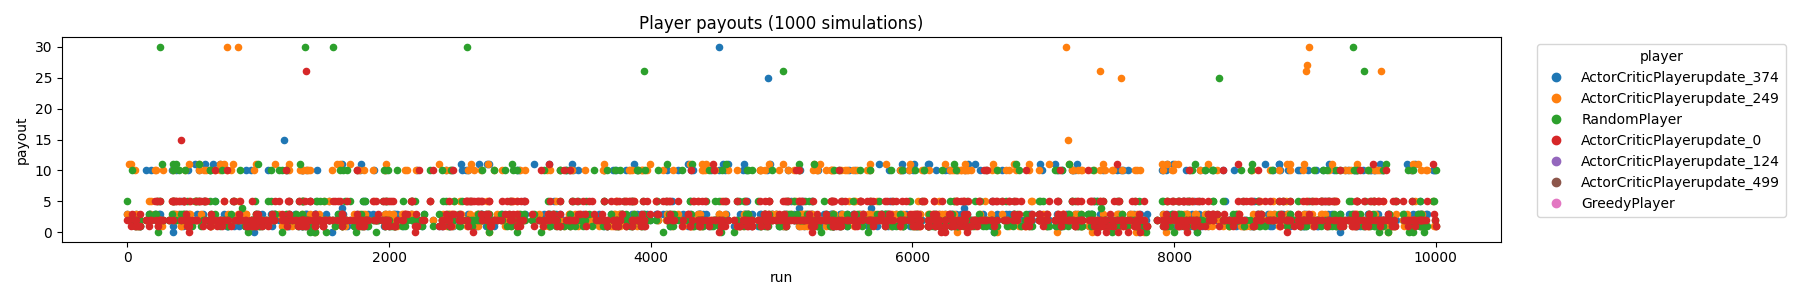

In [22]:
plot_game_payouts(game_results, max_plotted_games=1000)

### Trained player evolution


In [23]:
def player_payout_stats(game_results):
    player_cols = [col for col in game_results if col.startswith("player_")]
    payout_cols = [col for col in game_results if col.startswith("payout_")]
    player_count = len(player_cols)

    long_df = pd.concat(
        [
            game_results[[payout_cols[i], player_cols[i]]]
            .rename(columns={payout_cols[i]: "payout", player_cols[i]: "player"})
            .assign(game_id=game_results.index)
            for i in range(player_count)
        ],
        ignore_index=True,
    )

    # Margin-to-winner for every row (<= 0)
    winner_payout = long_df.groupby("game_id")["payout"].transform("max")
    long_df["margin_to_winner"] = long_df["payout"] - winner_payout

    summary = (
        long_df.groupby("player")["payout"]
        .agg(
            min="min",
            q1=lambda x: x.quantile(0.25),
            median="median",
            mean="mean",
            q3=lambda x: x.quantile(0.75),
            max="max",
        )
        .reset_index()
        .sort_values("mean", ascending=False)
        .reset_index(drop=True)
    )

    # Mean margin to winner (game-level dominance)
    mean_margin_to_winner = (
        long_df.groupby("player")["margin_to_winner"]
        .mean()
        .rename("mean_margin_to_winner")
    )

    summary = summary.merge(mean_margin_to_winner, on="player", how="left")
    summary["rank"] = summary.index + 1

    return summary

In [24]:
player_payout_stats(game_results)

,player,min,q1,median,mean,q3,max,mean_margin_to_winner,rank
0,ActorCriticPlayerupdate_499,0.0,2.0,2.0,4.159252,5.0,50.0,-2.708008,1
1,ActorCriticPlayerupdate_374,0.0,2.0,2.0,4.140682,5.0,50.0,-2.745057,2
2,ActorCriticPlayerupdate_249,0.0,2.0,2.0,3.876169,5.0,50.0,-2.639054,3
3,ActorCriticPlayerupdate_124,0.0,2.0,2.0,3.735126,5.0,50.0,-2.811795,4
4,GreedyPlayer,0.0,2.0,2.0,3.543730,3.0,30.0,-4.320513,5
5,ActorCriticPlayerupdate_0,0.0,1.0,2.0,2.309421,2.0,30.0,-4.303717,6
6,RandomPlayer,0.0,1.0,2.0,2.245093,2.0,30.0,-4.262423,7


### Per seat payouts


In [25]:
game_results[[c for c in game_results.columns if c.startswith("payout_")]].describe()

,payout_0,payout_1,payout_2,payout_3
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.457900,4.081900,3.329600,2.843000
std,3.434153,3.952108,3.287316,2.040678
min,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,2.000000,2.000000,2.000000,2.000000
75%,3.000000,5.000000,5.000000,5.000000
max,50.000000,50.000000,50.000000,26.000000


### Evaluate player trained at different steps against euristics

Take a player from step n, create games where it is the only trained one playing
against fixed euristics. Seats rotate.


In [26]:
SIMULATION_COUNT = 1_000

game_results = []
checkpoint_count_to_sample = 100
checkpoint_indexes = np.linspace(
    0, len(trained_players) - 1, checkpoint_count_to_sample, dtype=int
)
for checkpoint_index in tqdm(checkpoint_indexes, leave=True):
    trained_player = trained_players[checkpoint_index]
    players = [trained_player, GreedyPlayer(), GreedyPlayer(), RandomPlayer()]

    player_count = len(players)
    rows = []
    for simulation_idex in trange(SIMULATION_COUNT, leave=False):
        players = random.sample(players, 4)
        end_state = run_game(game, players)
        rows.append(end_state.returns() + [p.name for p in players])

    game_results.append(
        {
            "checkpoint_index": checkpoint_index,
            "results": pd.DataFrame(
                rows,
                columns=[f"payout_{i}" for i in range(player_count)]
                + [f"player_{i}" for i in range(player_count)],
            ),
        }
    )

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

,player,min,q1,median,mean,q3,max,mean_margin_to_winner,rank,checkpoint
checkpoint,,,,,,,,,,
0,ActorCriticPlayerupdate_0,0.0,2.0,2.0,3.572,3.0,30.0,-3.297,1,0
5,ActorCriticPlayerupdate_5,0.0,2.0,2.0,3.751,4.0,30.0,-3.554,2,5
10,ActorCriticPlayerupdate_10,0.0,2.0,2.0,4.413,5.0,30.0,-2.641,1,10
15,ActorCriticPlayerupdate_15,1.0,2.0,3.0,5.956,10.0,30.0,-2.109,1,15
20,ActorCriticPlayerupdate_20,0.0,2.0,3.0,5.666,10.0,30.0,-1.890,1,20
...,...,...,...,...,...,...,...,...,...,...
478,ActorCriticPlayerupdate_478,1.0,3.0,10.0,8.002,10.0,50.0,-1.006,1,478
483,ActorCriticPlayerupdate_483,1.0,2.0,10.0,8.356,10.0,50.0,-1.013,1,483
488,ActorCriticPlayerupdate_488,1.0,2.0,10.0,7.823,10.0,50.0,-1.021,1,488


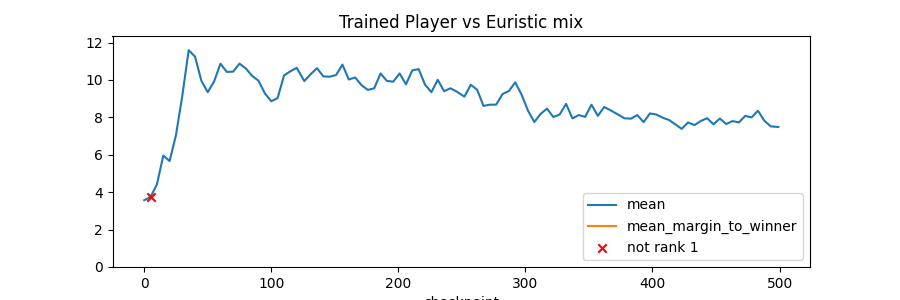

In [27]:
history_df = pd.concat(
    player_payout_stats(gr["results"])
    .loc[lambda r: r.player.str.startswith("ActorCriticPlayer")]
    .assign(checkpoint=gr["checkpoint_index"])
    for gr in game_results
).set_index("checkpoint", drop=False)

display(history_df)

columns_to_display = ["mean", "mean_margin_to_winner"]
ax = history_df[columns_to_display].plot(
    figsize=(9, 3), title="Trained Player vs Euristic mix", ylim=(0, None)
)

mask = history_df["rank"] != 1

for col in columns_to_display:
    ax.scatter(
        history_df.index[mask],
        history_df.loc[mask, col],
        marker="x",
        color="red",
        zorder=3,
        label="not rank 1" if col == "mean" else None,
    )
ax.legend()

### Evaluation with only trained players.


  0%|          | 0/10000 [00:00<?, ?it/s]

,player,min,q1,median,mean,q3,max,mean_margin_to_winner,rank,checkpoint
checkpoint,,,,,,,,,,
388,ActorCriticPlayerupdate_388,0.0,2.0,2.0,4.216324,5.0,30.0,-2.719329,1,388
443,ActorCriticPlayerupdate_443,0.0,2.0,2.0,4.208963,5.0,30.0,-2.818694,2,443
499,ActorCriticPlayerupdate_499,0.0,2.0,2.0,4.114762,5.0,30.0,-2.711725,3,499
332,ActorCriticPlayerupdate_332,0.0,2.0,2.0,4.088690,5.0,27.0,-2.879422,4,332
277,ActorCriticPlayerupdate_277,0.0,2.0,2.0,3.994757,5.0,30.0,-2.810237,5,277
221,ActorCriticPlayerupdate_221,0.0,2.0,2.0,3.620120,3.0,30.0,-2.918919,6,221
166,ActorCriticPlayerupdate_166,0.0,2.0,2.0,3.400449,4.0,30.0,-3.373503,7,166
110,ActorCriticPlayerupdate_110,0.0,2.0,2.0,3.163840,3.0,27.0,-3.501247,8,110
55,ActorCriticPlayerupdate_55,0.0,2.0,2.0,2.578385,3.0,11.0,-4.120248,9,55


<Axes: title={'center': 'Trained Player vs Trained Player'}, xlabel='checkpoint'>

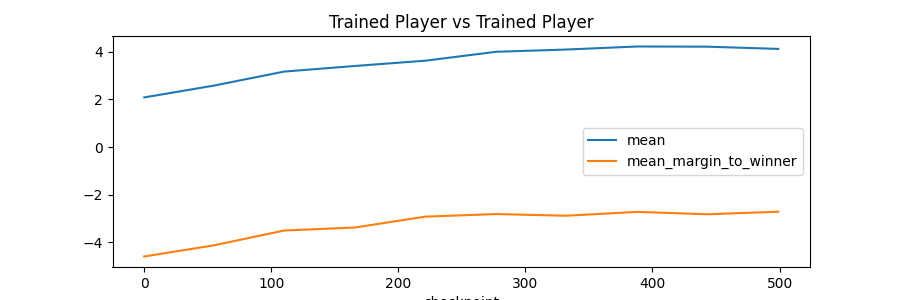

In [28]:
UPDATE_COUNT = 10
sampled_update_indexes = np.linspace(
    0, len(trained_players) - 1, UPDATE_COUNT, dtype=int
)
EVALUATION_PLAYERS = [trained_players[index] for index in sampled_update_indexes]
rows = []
for simulation_idex in trange(UPDATE_COUNT * SIMULATION_COUNT):
    players = random.sample(EVALUATION_PLAYERS, 4)
    player_count = len(players)
    end_state = run_game(game, players)
    rows.append(end_state.returns() + [p.name for p in players])

results = pd.DataFrame(
    rows,
    columns=[f"payout_{i}" for i in range(len(players))]
    + [f"player_{i}" for i in range(len(players))],
)

payout_stats = (
    player_payout_stats(results)
    .assign(
        checkpoint=lambda df: df["player"].str.extract(r"_(\d+)").astype(int)
    )
    .set_index("checkpoint", drop=False)
)
display(payout_stats)

payout_stats[["mean", "mean_margin_to_winner"]].sort_index().plot(
    figsize=(9, 3), title="Trained Player vs Trained Player"
)

In [29]:
player_payout_stats(results)

,player,min,q1,median,mean,q3,max,mean_margin_to_winner,rank
0,ActorCriticPlayerupdate_388,0.0,2.0,2.0,4.216324,5.0,30.0,-2.719329,1
1,ActorCriticPlayerupdate_443,0.0,2.0,2.0,4.208963,5.0,30.0,-2.818694,2
2,ActorCriticPlayerupdate_499,0.0,2.0,2.0,4.114762,5.0,30.0,-2.711725,3
3,ActorCriticPlayerupdate_332,0.0,2.0,2.0,4.088690,5.0,27.0,-2.879422,4
4,ActorCriticPlayerupdate_277,0.0,2.0,2.0,3.994757,5.0,30.0,-2.810237,5
5,ActorCriticPlayerupdate_221,0.0,2.0,2.0,3.620120,3.0,30.0,-2.918919,6
6,ActorCriticPlayerupdate_166,0.0,2.0,2.0,3.400449,4.0,30.0,-3.373503,7
7,ActorCriticPlayerupdate_110,0.0,2.0,2.0,3.163840,3.0,27.0,-3.501247,8
8,ActorCriticPlayerupdate_55,0.0,2.0,2.0,2.578385,3.0,11.0,-4.120248,9
9,ActorCriticPlayerupdate_0,0.0,1.0,2.0,2.080974,2.0,11.0,-4.589916,10


# Model selection

For this part we focus on full matches. That is, the first player to get to P
points gains the whole match.

## Selection process

1. Run few matches with all the checkpoints.
2. Select the K checkpoints with highiest winrate.
3. Run matches for the K selected checkpoints.
4. Select the best scoring checkpoint

### Scoring criteria (Highest winrate wins. Mostly)

1. Select checkpoints that are within $\epsilon$ from the one with highest winrate.
2. Select the ones within $\epsilon$ of the one with highest `lead_when_win`.
   Prefers ones that win confortably.
3. Select the one with highest `mean_deficit_when_lose` .
   Prefers ones that don't lose by much.


In [30]:
def run_match(
    players: list[Player], winning_score: int = 40
) -> tuple[dict, pd.DataFrame]:
    history = []

    scoreboard = {p: 0 for p in players}
    # Run until a player reaches winning score
    while max(r for r in scoreboard.values()) < winning_score:
        # play another game
        end_state = run_game(game, players)
        # update scoreboard
        for player, payout in zip(players, end_state.returns()):
            scoreboard[player] += int(payout)
        # rotate players
        players = players[1:] + players[:1]
        history.append(copy.deepcopy(scoreboard))

    history = [
        {p.name: score for p, score in score_dict.items()} for score_dict in history
    ]

    history_df = pd.DataFrame.from_records(history)

    history_df = history_df.loc[
        :, history_df.iloc[-1].sort_values(ascending=False).index
    ]

    return history[-1], history_df

,rank,win,lead_when_win,deficit_when_lose,gap_to_second,score_share,score
ActorCriticPlayerupdate_443,1,1.0,9.0,0.0,9,0.379630,41
ActorCriticPlayerupdate_166,2,0.0,0.0,-9.0,0,0.296296,32
ActorCriticPlayerupdate_110,3,0.0,0.0,-20.0,-11,0.194444,21
ActorCriticPlayerupdate_55,4,0.0,0.0,-27.0,-18,0.129630,14


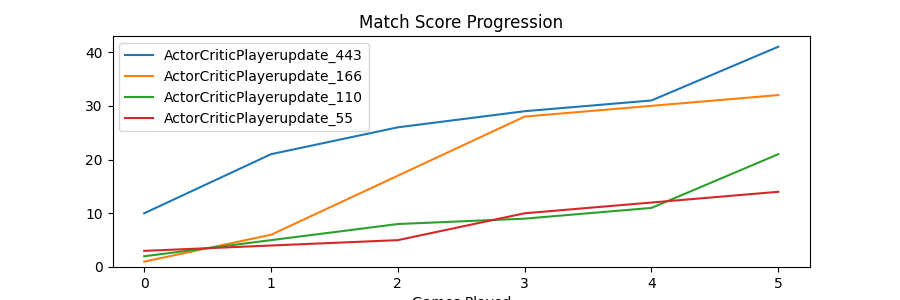

In [31]:
def match_metrics(scoreboard: dict) -> pd.DataFrame:
    """
    Compute per-player metrics from a single match result.

    scores: pd.Series[player_name -> score]
    returns: pd.DataFrame indexed by player_name
    """
    scores = pd.Series(scoreboard)
    scores = scores.sort_values(ascending=False)
    total = scores.sum()

    first_score = scores.iloc[0]
    second_score = scores.iloc[1] if len(scores) > 1 else scores.iloc[0]

    # handle ties for first
    winners = scores[scores == first_score]
    k_winners = len(winners)

    rows = {}

    for player, s in scores.items():
        rank = (scores > s).sum() + 1

        win_indicator = 0.0
        if s == first_score:
            win_indicator = 1.0 / k_winners

        lead_when_win = (s - second_score) if s == first_score else 0.0
        deficit_when_lose = (s - first_score) if s < first_score else 0.0

        gap_to_second = s - second_score

        rows[player] = {
            "rank": rank,
            "win": win_indicator,
            "lead_when_win": lead_when_win,
            "deficit_when_lose": deficit_when_lose,
            "gap_to_second": gap_to_second,
            "score_share": s / total,
            "score": s,
        }

    return pd.DataFrame.from_dict(rows, orient="index")


def match_metrics_aggregate(all_matches: list[pd.DataFrame]) -> pd.DataFrame:
    """
    Aggregate a list of per-match metrics DataFrames (output from match_metrics).

    Returns a DataFrame indexed by player_name with:
    - matches : number of matches the player participated in.
    - win_rate : fraction of matches won (ties count fractionally).
    - mean_lead_when_win : average score lead over the runner-up in matches the player won.
    - mean_deficit_when_lose : average score difference to the winner in matches the player lost (≤ 0).
    - mean_gap_to_second : average score difference to the second-place player (signed).
    - mean_score_share : average fraction of total match points captured by the player.
    - mean_score : average score.

    Players that never win or never lose have zeros for the corresponding conditional means.
    """
    df = pd.concat(all_matches, axis=0)  # index = player_name repeated across matches

    # group helper
    g = df.groupby(level=0)

    win_df = df[df["lead_when_win"] > 0]
    lose_df = df[df["deficit_when_lose"] < 0]

    out = pd.DataFrame(
        {
            "matches": g.size(),
            "win_rate": g["win"].mean(),
            "mean_lead_when_win": win_df.groupby(level=0)["lead_when_win"].mean(),
            "mean_deficit_when_lose": lose_df.groupby(level=0)[
                "deficit_when_lose"
            ].mean(),
            "mean_gap_to_second": g["gap_to_second"].mean(),
            "mean_score_share": g["score_share"].mean(),
            "mean_score": g["score"].mean(),
        }
    )

    # players that never won/never lost will have NaN in conditional means
    return out.fillna(0.0).sort_values(
        ["win_rate", "mean_lead_when_win"], ascending=False
    )


players = random.sample(EVALUATION_PLAYERS, 4)
scoreboard, history_df = run_match(players)

history_df.plot(
    figsize=(9, 3),
    title="Match Score Progression",
    xlabel="Games Played",
    ylim=(0, None),
)
display(match_metrics(history_df.iloc[-1]))

## Stage A: Coarse candidate selection


In [32]:
STAGE_A_PLAYERS = trained_players
PLAYERS_TO_KEEP = 20

matches_per_player = 10
candidates = STAGE_A_PLAYERS
total_rounds = math.ceil(
    math.log2(len(candidates) / PLAYERS_TO_KEEP)
)  # just for tqdm progress bar

with tqdm(
    total=total_rounds, desc="Stage A (successive halving)", unit="round"
) as rounds_pbar:
    while len(candidates) > PLAYERS_TO_KEEP:
        match_count = len(candidates) * matches_per_player // 4
        metrics = match_metrics_aggregate(
            [
                match_metrics(run_match(random.sample(candidates, 4))[0])
                for _ in trange(match_count, desc="Matches", leave=False)
            ]
        )
        keep_count = max(PLAYERS_TO_KEEP, len(candidates) // 2)
        player_names_to_keep = (
            metrics.sort_values("win_rate", ascending=False).head(keep_count).index
        )
        candidates = [p for p in candidates if p.name in player_names_to_keep]
        matches_per_player *= 2

        rounds_pbar.update(1)

STAGE_B_PLAYERS = candidates[:20]

Stage A (successive halving):   0%|          | 0/5 [00:00<?, ?round/s]

Matches:   0%|          | 0/1250 [00:00<?, ?it/s]

Matches:   0%|          | 0/1250 [00:00<?, ?it/s]

Matches:   0%|          | 0/1250 [00:00<?, ?it/s]

Matches:   0%|          | 0/1240 [00:00<?, ?it/s]

Matches:   0%|          | 0/1240 [00:00<?, ?it/s]

## Stage B: Final candidate selection


In [33]:
MATCH_COUNT = len(STAGE_B_PLAYERS) * 2_000 // 4

stage_b_metrics_df = match_metrics_aggregate(
    [
        match_metrics(run_match(random.sample(STAGE_B_PLAYERS, 4))[0])
        for _ in trange(MATCH_COUNT, desc="Matches")
    ]
)

bold_max = lambda s: ["font-weight: bold" if v == s.max() else "" for v in s]
stage_b_metrics_df.sort_values("win_rate", ascending=False).head(20).style.apply(
    bold_max, axis=0
)

Matches:   0%|          | 0/10000 [00:00<?, ?it/s]

,matches,win_rate,mean_lead_when_win,mean_deficit_when_lose,mean_gap_to_second,mean_score_share,mean_score
ActorCriticPlayerupdate_387,1995,0.268922,7.128655,-11.609484,-1.796491,0.252465,34.544361
ActorCriticPlayerupdate_495,1999,0.267550,6.875969,-11.698270,-1.732366,0.253146,34.362681
ActorCriticPlayerupdate_467,2016,0.267278,7.075000,-11.687929,-1.667163,0.252863,34.459325
ActorCriticPlayerupdate_444,2053,0.266764,6.981061,-11.690909,-1.892353,0.251566,34.363858
ActorCriticPlayerupdate_426,2007,0.262913,6.654762,-11.516151,-1.828600,0.252034,34.554559
ActorCriticPlayerupdate_456,2016,0.258805,7.208502,-11.634130,-1.759921,0.252883,34.444444
ActorCriticPlayerupdate_481,2035,0.256429,7.014085,-11.872226,-1.924816,0.250700,34.215233
ActorCriticPlayerupdate_432,1993,0.254474,6.770961,-11.757328,-2.001505,0.250263,34.177120
ActorCriticPlayerupdate_471,1985,0.252351,6.716942,-11.899045,-2.055416,0.250103,34.148615
ActorCriticPlayerupdate_346,2078,0.251805,6.942231,-12.012394,-2.180462,0.248462,33.911453


In [34]:
for player in STAGE_B_PLAYERS:
    player.export(f"checkpoints/{player.name}.pt")

## Apply selection criteria


In [35]:
def epsilon_lexicographic_select(
    df: pd.DataFrame, eps_win: float = 0.01, eps_lead: float = 0.5
) -> pd.Series:
    """
    Epsilon-lexicographic selection:
      1) Keep rows within eps_win of best win_rate.
      2) From those, keep rows within eps_lead of best mean_lead_when_win.
      3) From those, pick max mean_deficit_when_lose (least negative).
    Returns the selected row (as a Series).
    """
    # 1) win_rate filter
    best_win = df.win_rate.max()
    s1 = df[df.win_rate >= best_win - eps_win]

    # 2) lead_when_win filter (within eps_lead of best among s1)
    best_lead = s1.mean_lead_when_win.max()
    lead_thresh = (1.0 - eps_lead) * best_lead
    s2 = s1[s1.mean_lead_when_win >= lead_thresh]

    # 3) deficit_when_lose tiebreak (higher is better, closer to 0)
    return s2.sort_values(
        ["mean_deficit_when_lose", "win_rate", "mean_lead_when_win"],
        ascending=[False, False, False],
    ).iloc[0]

In [36]:
epsilon_lexicographic_select(stage_b_metrics_df)

matches                   2007.000000
win_rate                     0.262913
mean_lead_when_win           6.654762
mean_deficit_when_lose     -11.516151
mean_gap_to_second          -1.828600
mean_score_share             0.252034
mean_score                  34.554559
Name: ActorCriticPlayerupdate_426, dtype: float64

In [37]:
selected_player_name = epsilon_lexicographic_select(stage_b_metrics_df).name

In [38]:
selected_player = [
    STAGE_B_PLAYERS[i]
    for i, p in enumerate(STAGE_B_PLAYERS)
    if p.name == selected_player_name
][0]
selected_player

ActorCriticPlayerupdate_426

In [39]:
selected_player.export(Path("checkpoints/best_actor_critic_player.pt"))